<a href="https://colab.research.google.com/github/rypriyanka2005/Machine-Learning-Sem-4/blob/MLlabs/mlLAB8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A2: Training AND Gate with Step Activation Function
Converged after 134 epochs
Final weights: w0=-0.1000, w1=0.0500, w2=0.1000
Final error: 0.000000


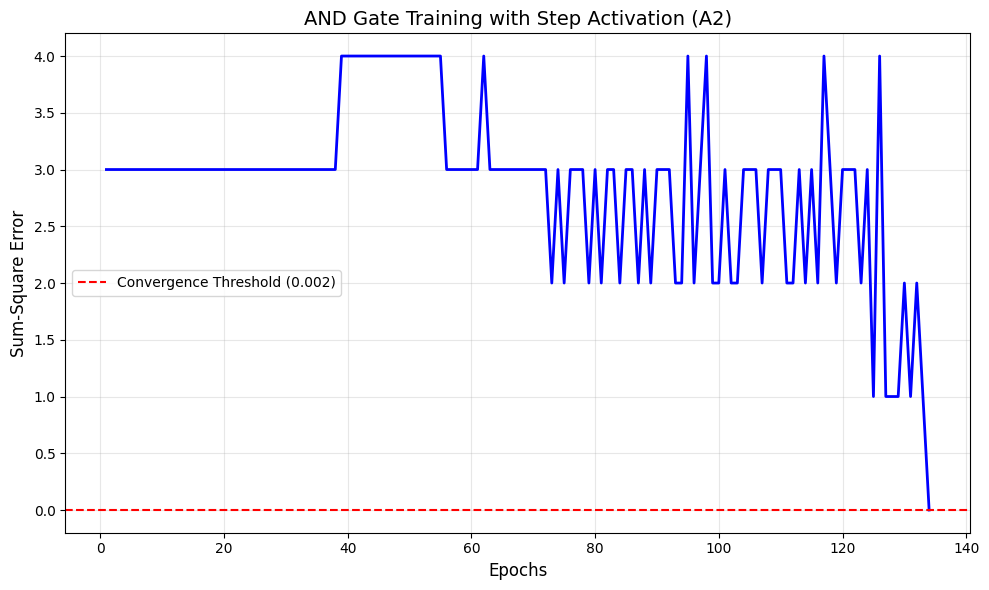


A3: Comparison of Different Activation Functions

Bipolar Step:
  Converged after 1000 epochs
  Final error: 3.000000
  Final weights: w0=-0.1000, w1=-0.0000, w2=0.0500

Sigmoid:
  Converged after 1000 epochs
  Final error: 0.042130
  Final weights: w0=-6.1354, w1=3.9618, w2=3.9615

ReLU:
  Converged after 394 epochs
  Final error: 0.001990
  Final weights: w0=-0.9284, w1=0.9501, w2=0.9498


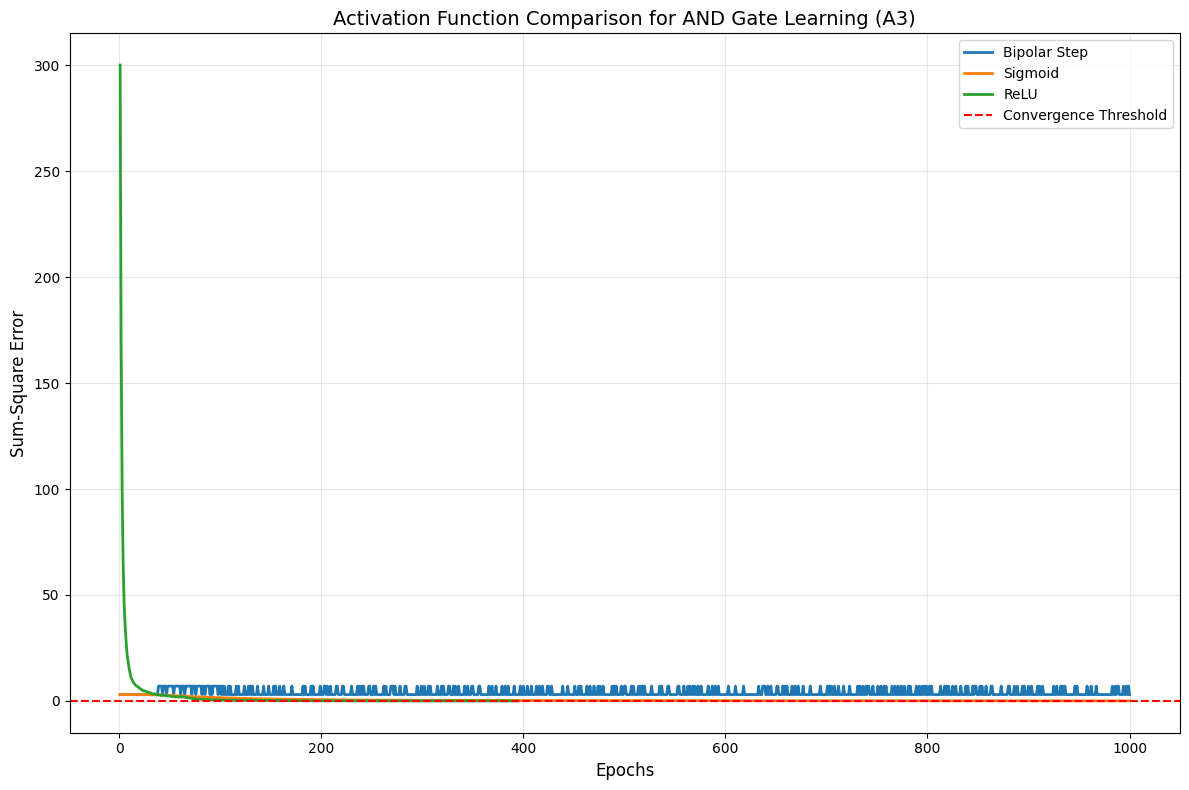


A4: Effect of Varying Learning Rate
Learning Rate = 0.1: Converged after 71 epochs
Learning Rate = 0.2: Converged after 41 epochs
Learning Rate = 0.3: Converged after 25 epochs
Learning Rate = 0.4: Converged after 26 epochs
Learning Rate = 0.5: Converged after 16 epochs
Learning Rate = 0.6: Converged after 20 epochs
Learning Rate = 0.7: Converged after 20 epochs
Learning Rate = 0.8: Converged after 14 epochs
Learning Rate = 0.9: Converged after 14 epochs
Learning Rate = 1.0: Converged after 16 epochs


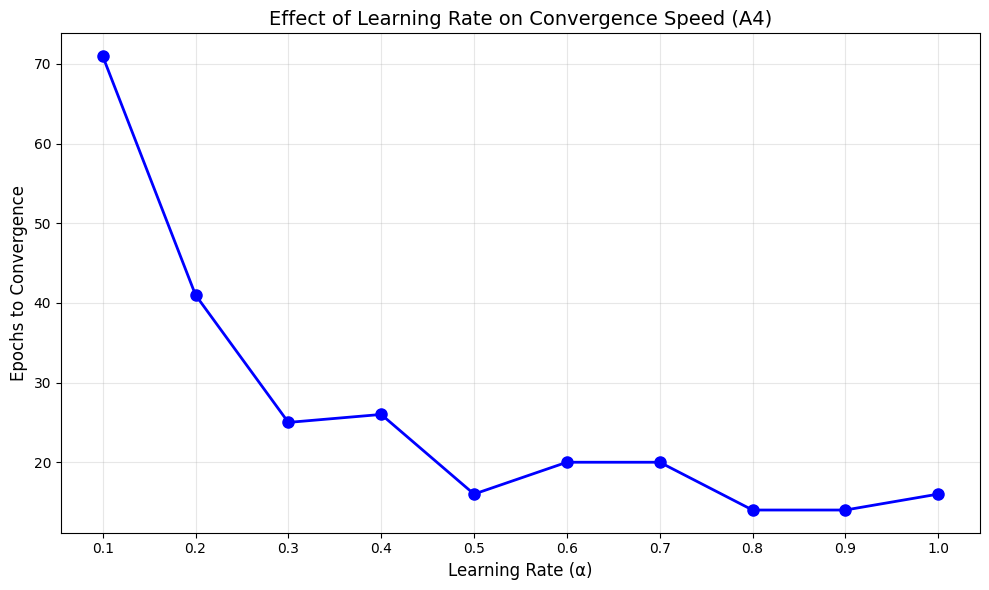


SUMMARY
A2 - Step Activation: 134 epochs
A3 - Bipolar Step: 1000 epochs
A3 - Sigmoid: 1000 epochs
A3 - ReLU: 394 epochs
A4 - Best learning rate: 0.8 (14 epochs)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# MODULE A1a: Summation Unit
# ============================================
def summation_unit(inputs, weights, bias):
    """
    Compute weighted sum of inputs plus bias.
    inputs: array of input values
    weights: array of weights corresponding to inputs
    bias: bias weight (w0)
    """
    return bias + np.dot(inputs, weights)


# ============================================
# MODULE A1b: Activation Functions
# ============================================
def step_activation(z, bipolar=False):
    """Step activation function (0 or 1) or Bipolar step (-1 or 1)"""
    if bipolar:
        return 1 if z >= 0 else -1
    else:
        return 1 if z >= 0 else 0


def bipolar_step_activation(z):
    """Bipolar step activation function (-1 or 1)"""
    return 1 if z >= 0 else -1


def sigmoid_activation(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-z))


def tanh_activation(z):
    """TanH activation function"""
    return np.tanh(z)


def relu_activation(z):
    """ReLU activation function"""
    return max(0, z)


def leaky_relu_activation(z, alpha=0.01):
    """Leaky ReLU activation function"""
    return z if z > 0 else alpha * z


# ============================================
# MODULE A1c: Comparator Unit for Error Calculation
# ============================================
def comparator_unit(predicted, actual):
    """Calculate error between predicted and actual output"""
    return actual - predicted


# ============================================
# Perceptron Training Function
# ============================================
def train_perceptron(X, y, activation_func, learning_rate=0.05,
                     initial_weights=None, max_epochs=1000,
                     convergence_error=0.002, activation_params=None):
    """
    Train a single perceptron using specified activation function.

    Parameters:
    X: input features (n_samples, n_features)
    y: target outputs
    activation_func: activation function to use
    learning_rate: alpha value
    initial_weights: [w0, w1, w2] where w0 is bias
    max_epochs: maximum number of epochs
    convergence_error: error threshold for convergence
    activation_params: additional parameters for activation functions

    Returns:
    weights: trained weights
    epoch_errors: list of sum-square errors per epoch
    epochs_taken: number of epochs to converge
    """
    n_samples, n_features = X.shape

    # Initialize weights
    if initial_weights is None:
        weights = np.zeros(n_features + 1)  # +1 for bias
    else:
        weights = np.array(initial_weights)  # [w0, w1, w2]

    epoch_errors = []
    epochs_taken = 0

    for epoch in range(max_epochs):
        total_error = 0

        # Shuffle data for better convergence
        indices = np.random.permutation(n_samples)

        for idx in indices:
            # Get sample
            x_sample = X[idx]
            y_true = y[idx]

            # Summation unit
            z = summation_unit(x_sample, weights[1:], weights[0])

            # Activation unit - handle different function signatures
            if activation_params and 'bipolar' in activation_params:
                y_pred = activation_func(z)  # Bipolar step doesn't need extra param
            else:
                y_pred = activation_func(z)

            # Comparator unit (error calculation)
            error = comparator_unit(y_pred, y_true)

            # Update weights (perceptron learning rule)
            weights[0] += learning_rate * error  # bias update
            for i in range(n_features):
                weights[i + 1] += learning_rate * error * x_sample[i]

            # Accumulate squared error for this sample
            total_error += error ** 2

        # Calculate sum-square error for this epoch
        epoch_errors.append(total_error)

        # Check convergence
        if total_error <= convergence_error:
            epochs_taken = epoch + 1
            break

    if epochs_taken == 0:
        epochs_taken = max_epochs

    return weights, epoch_errors, epochs_taken


# ============================================
# AND Gate Data
# ============================================
def get_and_gate_data():
    """Return AND gate input-output pairs"""
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
    y = np.array([0, 0, 0, 1])
    return X, y


# ============================================
# XOR Gate Data (for reference)
# ============================================
def get_xor_gate_data():
    """Return XOR gate input-output pairs"""
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
    y = np.array([0, 1, 1, 0])
    return X, y


# ============================================
# Main Program
# ============================================
def main():
    # Get AND gate data
    X_and, y_and = get_and_gate_data()

    # Initial weights and learning rate from A1
    initial_weights = [10, 0.2, -0.75]  # [w0, w1, w2]
    learning_rate = 0.05

    print("=" * 60)
    print("A2: Training AND Gate with Step Activation Function")
    print("=" * 60)

    # Train with step activation
    weights_step, errors_step, epochs_step = train_perceptron(
        X_and, y_and,
        activation_func=step_activation,
        learning_rate=learning_rate,
        initial_weights=initial_weights,
        max_epochs=1000,
        convergence_error=0.002,
        activation_params={'bipolar': False}
    )

    print(f"Converged after {epochs_step} epochs")
    print(f"Final weights: w0={weights_step[0]:.4f}, w1={weights_step[1]:.4f}, w2={weights_step[2]:.4f}")
    print(f"Final error: {errors_step[-1]:.6f}")

    # Plot epoch vs error for A2
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(errors_step) + 1), errors_step, 'b-', linewidth=2)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Sum-Square Error', fontsize=12)
    plt.title('AND Gate Training with Step Activation (A2)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0.002, color='r', linestyle='--', label='Convergence Threshold (0.002)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================================
    # A3: Compare different activation functions
    # ============================================
    print("\n" + "=" * 60)
    print("A3: Comparison of Different Activation Functions")
    print("=" * 60)

    activation_functions = {
        'Bipolar Step': (bipolar_step_activation, {}),
        'Sigmoid': (sigmoid_activation, {}),
        'ReLU': (relu_activation, {})
    }

    results_a3 = {}

    for act_name, (act_func, params) in activation_functions.items():
        weights, errors, epochs = train_perceptron(
            X_and, y_and,
            activation_func=act_func,
            learning_rate=learning_rate,
            initial_weights=initial_weights,
            max_epochs=1000,
            convergence_error=0.002,
            activation_params=params
        )
        results_a3[act_name] = {
            'epochs': epochs,
            'final_error': errors[-1],
            'weights': weights,
            'errors': errors
        }
        print(f"\n{act_name}:")
        print(f"  Converged after {epochs} epochs")
        print(f"  Final error: {errors[-1]:.6f}")
        print(f"  Final weights: w0={weights[0]:.4f}, w1={weights[1]:.4f}, w2={weights[2]:.4f}")

    # Plot comparison for A3
    plt.figure(figsize=(12, 8))
    for act_name, data in results_a3.items():
        plt.plot(range(1, len(data['errors']) + 1), data['errors'],
                label=act_name, linewidth=2)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Sum-Square Error', fontsize=12)
    plt.title('Activation Function Comparison for AND Gate Learning (A3)', fontsize=14)
    plt.axhline(y=0.002, color='r', linestyle='--', label='Convergence Threshold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================================
    # A4: Varying learning rate
    # ============================================
    print("\n" + "=" * 60)
    print("A4: Effect of Varying Learning Rate")
    print("=" * 60)

    learning_rates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    epochs_vs_lr = []

    for lr in learning_rates:
        weights, errors, epochs = train_perceptron(
            X_and, y_and,
            activation_func=step_activation,
            learning_rate=lr,
            initial_weights=initial_weights,
            max_epochs=1000,
            convergence_error=0.002,
            activation_params={'bipolar': False}
        )
        epochs_vs_lr.append(epochs)
        status = "Converged" if epochs < 1000 else "Did not converge"
        print(f"Learning Rate = {lr:.1f}: {status} after {epochs} epochs")

    # Plot for A4
    plt.figure(figsize=(10, 6))
    plt.plot(learning_rates, epochs_vs_lr, 'bo-', linewidth=2, markersize=8)
    plt.xlabel('Learning Rate (α)', fontsize=12)
    plt.ylabel('Epochs to Convergence', fontsize=12)
    plt.title('Effect of Learning Rate on Convergence Speed (A4)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.xticks(learning_rates)
    plt.tight_layout()
    plt.show()

    # Summary table
    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"A2 - Step Activation: {epochs_step} epochs")
    for act_name, data in results_a3.items():
        print(f"A3 - {act_name}: {data['epochs']} epochs")

    # Find best learning rate (ignoring non-converged ones)
    valid_epochs = [e if e < 1000 else 9999 for e in epochs_vs_lr]
    best_lr_index = np.argmin(valid_epochs)
    if epochs_vs_lr[best_lr_index] < 1000:
        print(f"A4 - Best learning rate: {learning_rates[best_lr_index]} ({epochs_vs_lr[best_lr_index]} epochs)")
    else:
        print("A4 - No learning rate achieved convergence within 1000 epochs")


# ============================================
# Run the main program
# ============================================
if __name__ == "__main__":
    main()

A2: Training AND Gate with Step Activation Function
Converged after 131 epochs
Final weights: w0=-0.1000, w1=0.0500, w2=0.1000
Final error: 0.000000


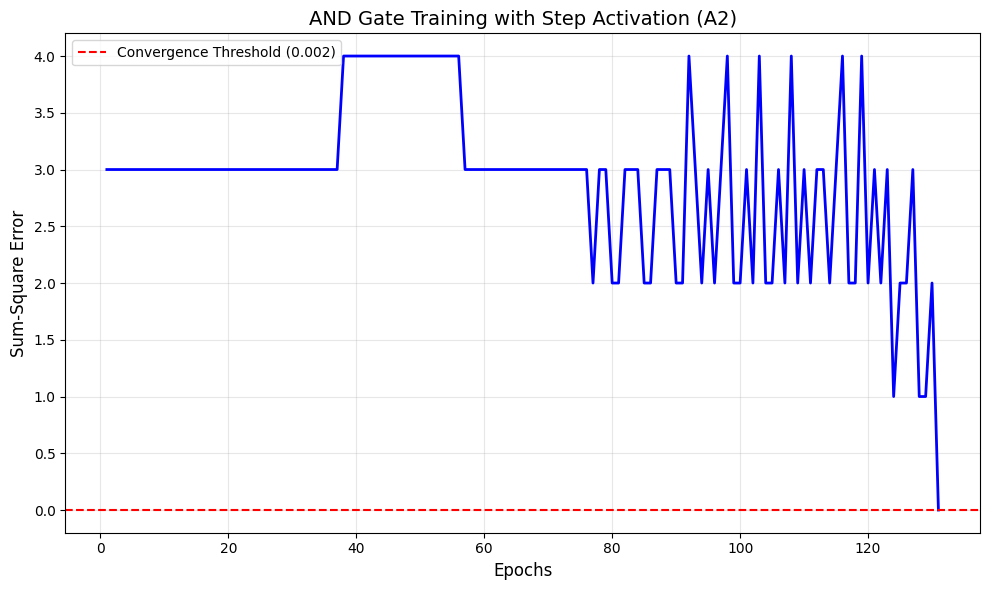


A3: Comparison of Different Activation Functions

Bipolar Step:
  Converged after 1000 epochs
  Final error: 3.000000
  Final weights: w0=-0.1000, w1=-0.0000, w2=0.0500

Sigmoid:
  Converged after 1000 epochs
  Final error: 0.042143
  Final weights: w0=-6.1357, w1=3.9617, w2=3.9608

ReLU:
  Converged after 395 epochs
  Final error: 0.001984
  Final weights: w0=-0.9290, w1=0.9498, w2=0.9497


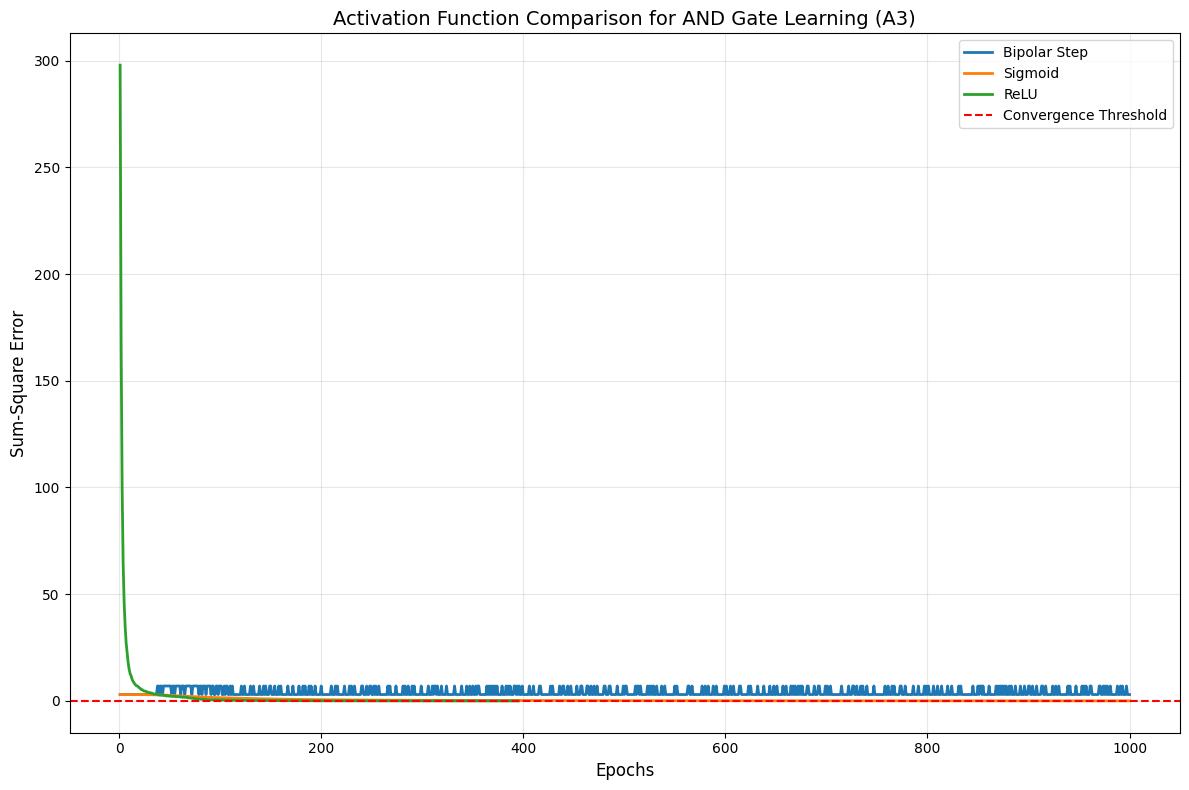


A4: Effect of Varying Learning Rate
Learning Rate = 0.1: Converged after 67 epochs
Learning Rate = 0.2: Converged after 37 epochs
Learning Rate = 0.3: Converged after 23 epochs
Learning Rate = 0.4: Converged after 26 epochs
Learning Rate = 0.5: Converged after 19 epochs
Learning Rate = 0.6: Converged after 18 epochs
Learning Rate = 0.7: Converged after 16 epochs
Learning Rate = 0.8: Converged after 15 epochs
Learning Rate = 0.9: Converged after 13 epochs
Learning Rate = 1.0: Converged after 16 epochs


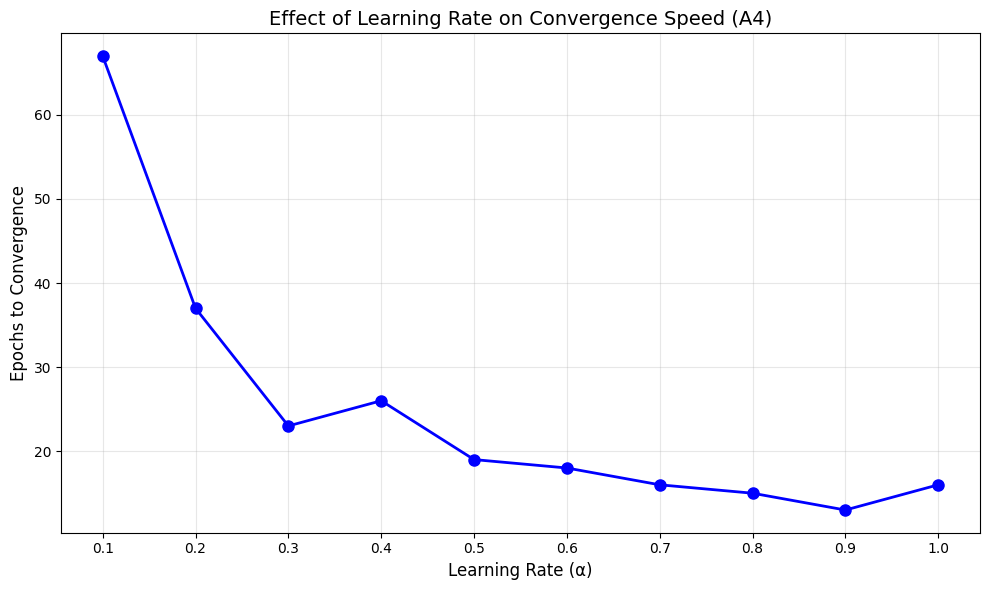


SUMMARY
A2 - Step Activation: 129 epochs
A3 - Bipolar Step: 1000 epochs
A3 - Sigmoid: 1000 epochs
A3 - ReLU: 395 epochs
A4 - Best learning rate: 0.9 (13 epochs)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

initial_weights = [10, 0.2, -0.75]
learning_rate = 0.05

print("=" * 60)
print("A2: Training AND Gate with Step Activation Function")
print("=" * 60)

n_samples, n_features = X_and.shape
weights = np.array(initial_weights)
max_epochs = 1000
convergence_error = 0.002
epoch_errors = []
epochs_taken = 0

for epoch in range(max_epochs):
    total_error = 0
    indices = np.random.permutation(n_samples)

    for idx in indices:
        x_sample = X_and[idx]
        y_true = y_and[idx]

        z = weights[0] + np.dot(x_sample, weights[1:])

        y_pred = 1 if z >= 0 else 0

        error = y_true - y_pred

        weights[0] += learning_rate * error
        for i in range(n_features):
            weights[i + 1] += learning_rate * error * x_sample[i]

        total_error += error ** 2

    epoch_errors.append(total_error)

    if total_error <= convergence_error:
        epochs_taken = epoch + 1
        break

if epochs_taken == 0:
    epochs_taken = max_epochs

print(f"Converged after {epochs_taken} epochs")
print(f"Final weights: w0={weights[0]:.4f}, w1={weights[1]:.4f}, w2={weights[2]:.4f}")
print(f"Final error: {epoch_errors[-1]:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(epoch_errors) + 1), epoch_errors, 'b-', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Sum-Square Error', fontsize=12)
plt.title('AND Gate Training with Step Activation (A2)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0.002, color='r', linestyle='--', label='Convergence Threshold (0.002)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("A3: Comparison of Different Activation Functions")
print("=" * 60)

activation_functions = {
    'Bipolar Step': 'bipolar',
    'Sigmoid': 'sigmoid',
    'ReLU': 'relu'
}

results_a3 = {}

for act_name, act_type in activation_functions.items():
    weights = np.array(initial_weights)
    epoch_errors = []
    epochs_taken = 0

    for epoch in range(max_epochs):
        total_error = 0
        indices = np.random.permutation(n_samples)

        for idx in indices:
            x_sample = X_and[idx]
            y_true = y_and[idx]

            z = weights[0] + np.dot(x_sample, weights[1:])

            if act_type == 'bipolar':
                y_pred = 1 if z >= 0 else -1
            elif act_type == 'sigmoid':
                y_pred = 1 / (1 + np.exp(-z))
            elif act_type == 'relu':
                y_pred = max(0, z)

            error = y_true - y_pred

            weights[0] += learning_rate * error
            for i in range(n_features):
                weights[i + 1] += learning_rate * error * x_sample[i]

            total_error += error ** 2

        epoch_errors.append(total_error)

        if total_error <= convergence_error:
            epochs_taken = epoch + 1
            break

    if epochs_taken == 0:
        epochs_taken = max_epochs

    results_a3[act_name] = {
        'epochs': epochs_taken,
        'final_error': epoch_errors[-1],
        'weights': weights,
        'errors': epoch_errors
    }
    print(f"\n{act_name}:")
    print(f"  Converged after {epochs_taken} epochs")
    print(f"  Final error: {epoch_errors[-1]:.6f}")
    print(f"  Final weights: w0={weights[0]:.4f}, w1={weights[1]:.4f}, w2={weights[2]:.4f}")

plt.figure(figsize=(12, 8))
for act_name, data in results_a3.items():
    plt.plot(range(1, len(data['errors']) + 1), data['errors'],
            label=act_name, linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Sum-Square Error', fontsize=12)
plt.title('Activation Function Comparison for AND Gate Learning (A3)', fontsize=14)
plt.axhline(y=0.002, color='r', linestyle='--', label='Convergence Threshold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("A4: Effect of Varying Learning Rate")
print("=" * 60)

learning_rates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
epochs_vs_lr = []

for lr in learning_rates:
    weights = np.array(initial_weights)
    epoch_errors = []
    epochs_taken = 0

    for epoch in range(max_epochs):
        total_error = 0
        indices = np.random.permutation(n_samples)

        for idx in indices:
            x_sample = X_and[idx]
            y_true = y_and[idx]

            z = weights[0] + np.dot(x_sample, weights[1:])

            y_pred = 1 if z >= 0 else 0

            error = y_true - y_pred

            weights[0] += lr * error
            for i in range(n_features):
                weights[i + 1] += lr * error * x_sample[i]

            total_error += error ** 2

        epoch_errors.append(total_error)

        if total_error <= convergence_error:
            epochs_taken = epoch + 1
            break

    if epochs_taken == 0:
        epochs_taken = max_epochs

    epochs_vs_lr.append(epochs_taken)
    status = "Converged" if epochs_taken < 1000 else "Did not converge"
    print(f"Learning Rate = {lr:.1f}: {status} after {epochs_taken} epochs")

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, epochs_vs_lr, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Learning Rate (α)', fontsize=12)
plt.ylabel('Epochs to Convergence', fontsize=12)
plt.title('Effect of Learning Rate on Convergence Speed (A4)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(learning_rates)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

weights_step = np.array(initial_weights)
epoch_errors_step = []
epochs_step = 0

for epoch in range(max_epochs):
    total_error = 0
    indices = np.random.permutation(n_samples)

    for idx in indices:
        x_sample = X_and[idx]
        y_true = y_and[idx]

        z = weights_step[0] + np.dot(x_sample, weights_step[1:])
        y_pred = 1 if z >= 0 else 0
        error = y_true - y_pred

        weights_step[0] += learning_rate * error
        for i in range(n_features):
            weights_step[i + 1] += learning_rate * error * x_sample[i]

        total_error += error ** 2

    epoch_errors_step.append(total_error)

    if total_error <= convergence_error:
        epochs_step = epoch + 1
        break

if epochs_step == 0:
    epochs_step = max_epochs

print(f"A2 - Step Activation: {epochs_step} epochs")
for act_name, data in results_a3.items():
    print(f"A3 - {act_name}: {data['epochs']} epochs")

valid_epochs = [e if e < 1000 else 9999 for e in epochs_vs_lr]
best_lr_index = np.argmin(valid_epochs)
if epochs_vs_lr[best_lr_index] < 1000:
    print(f"A4 - Best learning rate: {learning_rates[best_lr_index]} ({epochs_vs_lr[best_lr_index]} epochs)")
else:
    print("A4 - No learning rate achieved convergence within 1000 epochs")

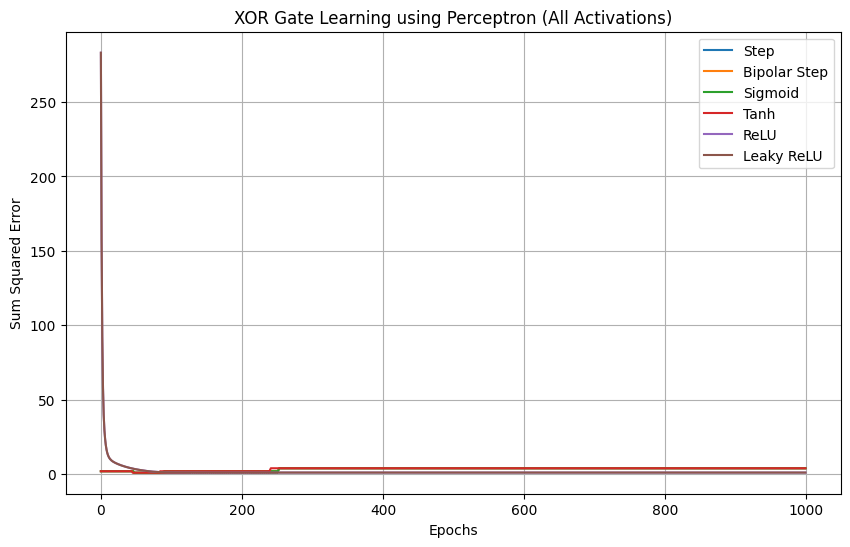

Step: Final Error = 4, Epochs = 1000
Bipolar Step: Final Error = 4, Epochs = 1000
Sigmoid: Final Error = 4, Epochs = 1000
Tanh: Final Error = 4, Epochs = 1000
ReLU: Final Error = 1.108033240997231, Epochs = 1000
Leaky ReLU: Final Error = 1.108033240997231, Epochs = 1000


/tmp/ipykernel_8511/172972930.py:130: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


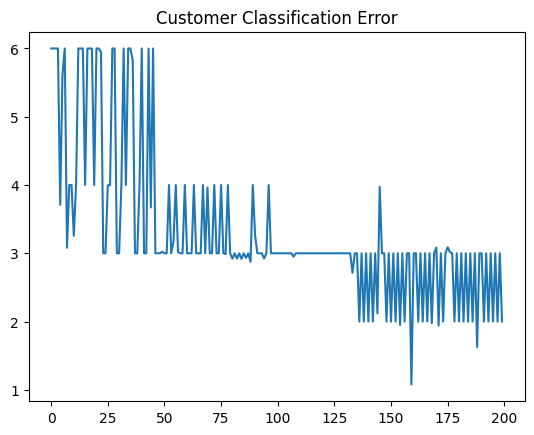

Weights (Pseudo Inverse): [ 0.1139903  -0.02789923  0.01473739 -0.04323249  0.00447248]


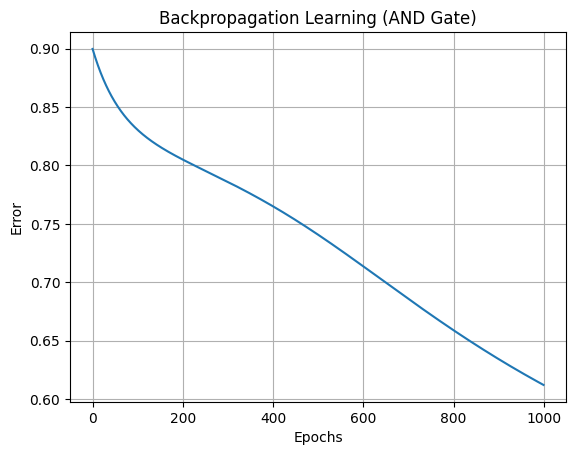

Final Weights:
 {'V11': -0.608911190465357, 'V12': -1.0350358101547317, 'V21': -0.9215648637883709, 'V22': 0.2514786575559635, 'W1': -1.9533827265874595, 'W2': -0.8374371795213713}

Final Error:
 0.6121106309105695

Epochs:
 1000

A9: XOR Gate Results
Epochs: 1000
Final Error: 2
Weights: [-7.64666108e-15  3.19189120e-16 -5.00000000e-02]

A10: Two Output Node Results
Final Weights:
 [[ 0.98779657 -0.06925614 -0.96372298]
 [-1.3432181   0.06811968  1.28516839]]
A11: XOR Predictions
[0 1 1 0]
Keys in dataset: ['features', 'labels', 'label_names']
Shape of X: (633, 4096)
Shape of y: (633,)

 Results:
Accuracy: 0.3228346456692913


In [6]:
# q5

import numpy as np
import matplotlib.pyplot as plt

# A1(a) Summation Unit
def summation_unit(x, w):
    total = 0
    for i in range(len(x)):
        total += x[i] * w[i]
    return total

# A1(b) Activation Functions=
def step(x):
    return 1 if x >= 0 else 0

def bipolar_step(x):
    return 1 if x >= 0 else -1

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return x if x > 0 else 0

def leaky_relu(x):
    return x if x > 0 else 0.01 * x


# A1(c) Comparator Unit (Error Calculation)
def comparator(target, output):
    return target - output


# Perceptron Training Function
def train_perceptron(X, y, activation_func, lr=0.05, max_epochs=1000):
    # Initial weights (bias + inputs)
    w = [10, 0.2, -0.75]

    errors = []

    for epoch in range(max_epochs):
        total_error = 0

        for i in range(len(X)):
            # Add bias input
            x_i = [1] + list(X[i])

            # Summation
            net = summation_unit(x_i, w)

            # Activation
            out = activation_func(net)

            # Convert outputs for consistency
            if activation_func in [sigmoid, tanh]:
                out = 1 if out >= 0.5 else 0
            elif activation_func == bipolar_step:
                out = 1 if out == 1 else 0

            # Error
            error = comparator(y[i], out)

            # Weight update
            for j in range(len(w)):
                w[j] = w[j] + lr * error * x_i[j]

            total_error += error ** 2

        errors.append(total_error)

        # Convergence condition
        if total_error <= 0.002:
            break

    return w, errors


X = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

y = [0, 1, 1, 0]


activations = {
    "Step": step,
    "Bipolar Step": bipolar_step,
    "Sigmoid": sigmoid,
    "Tanh": tanh,
    "ReLU": relu,
    "Leaky ReLU": leaky_relu
}

results = {}

for name, func in activations.items():
    w, errors = train_perceptron(X, y, func)
    results[name] = errors


# Plot Results
plt.figure(figsize=(10,6))

for name, errors in results.items():
    plt.plot(errors, label=name)

plt.xlabel("Epochs")
plt.ylabel("Sum Squared Error")
plt.title("XOR Gate Learning using Perceptron (All Activations)")
plt.legend()
plt.grid()
plt.show()

for name, errors in results.items():
    print(f"{name}: Final Error = {errors[-1]}, Epochs = {len(errors)}")



#q6

# Sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def train_sigmoid(X, y, lr, epochs):
    w = np.random.randn(X.shape[1] + 1)
    errors = []

    for epoch in range(epochs):
        total_error = 0
        for i in range(len(X)):
            x_i = np.insert(X[i], 0, 1)
            net = np.dot(w, x_i)
            out = sigmoid(net)

            error = y[i] - out
            w += lr * error * x_i
            total_error += error**2

        errors.append(total_error)

    return w, errors

# Data
X = np.array([
    [20,6,2,386],[16,3,6,289],[27,6,2,393],[19,1,2,110],
    [24,4,2,280],[22,1,5,167],[15,4,2,271],[18,4,2,274],
    [21,1,4,148],[16,2,4,198]
])

y = np.array([1,1,1,0,1,0,1,1,0,0])

w, errors = train_sigmoid(X, y, 0.01, 200)

plt.plot(errors)
plt.title("Customer Classification Error")
plt.show()



# q7

def pseudo_inverse_solution(X, y):
    X_bias = np.c_[np.ones(X.shape[0]), X]
    w = np.linalg.pinv(X_bias).dot(y)
    return w

w_pinv = pseudo_inverse_solution(X, y)
print("Weights (Pseudo Inverse):", w_pinv)



# q8

import numpy as np
import matplotlib.pyplot as plt

# Sigmoid + derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training Function (Backprop)
def train_nn(X, y, lr=0.05, max_epochs=1000):

    # Initialize weights with random values
    V11, V12 = 0.5, -0.5   # A → H1, H2
    V21, V22 = 0.3, 0.8    # B → H1, H2

    W1, W2 = -0.7, 0.2     # H1, H2 → Output

    errors = []

    for epoch in range(max_epochs):
        total_error = 0

        for i in range(len(X)):
            A, B = X[i]
            target = y[i]

            # FORWARD PASS
            H1_in = A * V11 + B * V21
            H2_in = A * V12 + B * V22

            H1 = sigmoid(H1_in)
            H2 = sigmoid(H2_in)

            O_in = H1 * W1 + H2 * W2
            O = sigmoid(O_in)

            # ERROR
            error = target - O
            total_error += error**2

            # BACKPROPAGATION
            delta_O = error * sigmoid_derivative(O)

            delta_H1 = delta_O * W1 * sigmoid_derivative(H1)
            delta_H2 = delta_O * W2 * sigmoid_derivative(H2)

            # WEIGHT UPDATES
            W1 += lr * delta_O * H1
            W2 += lr * delta_O * H2

            V11 += lr * delta_H1 * A
            V21 += lr * delta_H1 * B

            V12 += lr * delta_H2 * A
            V22 += lr * delta_H2 * B

        errors.append(total_error)

        # Convergence check
        if total_error <= 0.002:
            break

    weights = {
        "V11": V11, "V12": V12,
        "V21": V21, "V22": V22,
        "W1": W1, "W2": W2
    }
    weights = {k: float(v) for k, v in weights.items()}

    return weights, errors


# AND Gate Dataset
X = [(0,0), (0,1), (1,0), (1,1)]
y = [0, 0, 0, 1]

# Train
weights, errors = train_nn(X, y)

# Plot
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Backpropagation Learning (AND Gate)")
plt.grid()
plt.show()

print("Final Weights:\n", weights)
print("\nFinal Error:\n", errors[-1])
print("\nEpochs:\n", len(errors))



# A9: XOR Gate using Step Activation (Perceptron)

X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

weights = np.array(initial_weights)
epoch_errors = []
epochs_taken = 0

for epoch in range(max_epochs):
    total_error = 0
    indices = np.random.permutation(len(X_xor))

    for idx in indices:
        x_sample = X_xor[idx]
        y_true = y_xor[idx]

        z = weights[0] + np.dot(x_sample, weights[1:])
        y_pred = 1 if z >= 0 else 0

        error = y_true - y_pred

        weights[0] += learning_rate * error
        weights[1:] += learning_rate * error * x_sample

        total_error += error ** 2

    epoch_errors.append(total_error)

    if total_error <= convergence_error:
        epochs_taken = epoch + 1
        break

if epochs_taken == 0:
    epochs_taken = max_epochs

print("\nA9: XOR Gate Results")
print(f"Epochs: {epochs_taken}")
print(f"Final Error: {epoch_errors[-1]}")
print(f"Weights: {weights}")

#A10

X = X_and
y_multi = np.array([[1, 0], [1, 0], [1, 0], [0, 1]])

weights = np.random.randn(2, 3)  # 2 outputs, 2 features + bias

epoch_errors = []

for epoch in range(max_epochs):
    total_error = 0

    for i in range(len(X)):
        x = np.insert(X[i], 0, 1)  # add bias
        target = y_multi[i]

        z = np.dot(weights, x)
        y_pred = np.where(z >= 0, 1, 0)

        error = target - y_pred

        weights += learning_rate * error.reshape(2,1) * x

        total_error += np.sum(error**2)

    epoch_errors.append(total_error)

    if total_error <= convergence_error:
        break

print("\nA10: Two Output Node Results")
print("Final Weights:\n", weights)

#A11



from sklearn.neural_network import MLPClassifier

# XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Improved MLP
mlp_xor = MLPClassifier(
    hidden_layer_sizes=(4, 2),   # more capacity
    activation='tanh',           # better than sigmoid here
    solver='adam',
    learning_rate_init=0.01,
    max_iter=5000,
    random_state=42
)

mlp_xor.fit(X_xor, y_xor)

print("A11: XOR Predictions")
print(mlp_xor.predict(X_xor))

#A12: MLP on fc7_feature.npz dataset

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Load dataset
data = np.load("/content/fc7_features.npz")

print("Keys in dataset:", data.files)

# Usually npz has something like 'X' and 'y'
# Check and assign properly
X = data[data.files[0]]
y = data[data.files[1]]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (VERY IMPORTANT for MLP)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

# Train
mlp.fit(X_train, y_train)

# Evaluate
accuracy = mlp.score(X_test, y_test)

print("\n Results:")
print("Accuracy:", accuracy)

# Optional: predictions
y_pred = mlp.predict(X_test)




